# TextCNN k4 — DROPOUT=0.7



In [ ]:
!git clone https://github.com/hyperformancelabs/vnlegal-rag.git
%cd vnlegal-rag
!cat data/word2vec/word2vec_part_* > data/word2vec/merged.zip
!7z x data/word2vec/merged.zip -odata/word2vec/ -y


Cloning into 'vnlegal-rag'...
remote: Enumerating objects: 436, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 436 (delta 8), reused 21 (delta 6), pack-reused 401 (from 2)
Receiving objects: 100% (436/436), 1.53 GiB | 17.04 MiB/s, done.
Resolving deltas: 100% (177/177), done.


In [ ]:
!git fetch origin
!git reset --hard origin/$(git branch --show-current)
!git clean -fd

HEAD is now at 13e4cb4 fix: TextCNN supports from_pretrained word2vec embedding natively


: 

In [1]:
%cd vnlegal-rag

/content/vnlegal-rag


In [2]:
import json, random, math
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset

from src.tokenizer import build_vocab, build_embedding_matrix, encode_text, simple_tokenize, PAD_TOKEN, UNK_TOKEN
from src.models.classifier import TextCNN


In [3]:
# Device and seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [4]:
# Data and artifact paths
DATA_DIR = Path('data/data_ready_k4')
ARTIFACT_DIR = Path('experiments/textcnn_artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('DATA_DIR =', DATA_DIR)
print('ARTIFACT_DIR =', ARTIFACT_DIR)


DATA_DIR = data/data_ready_k4
ARTIFACT_DIR = experiments/textcnn_artifacts


In [5]:
# Load QA splits
qa_train = pd.read_csv(DATA_DIR / 'qa_train.csv', sep='	')
qa_val   = pd.read_csv(DATA_DIR / 'qa_val.csv', sep='	')
qa_test  = pd.read_csv(DATA_DIR / 'qa_test.csv', sep='	')

required = {'question', 'answer', 'macro_domain'}
for name, df in [('train', qa_train), ('val', qa_val), ('test', qa_test)]:
    miss = required - set(df.columns)
    if miss:
        raise ValueError(f'{name} missing: {miss}')

print('train:', qa_train.shape, 'val:', qa_val.shape, 'test:', qa_test.shape)


train: (23408, 12) val: (2902, 12) test: (2832, 12)


In [6]:
# Load labels
lm_path = DATA_DIR / 'label_maps.json'
if lm_path.exists():
    with open(lm_path, 'r', encoding='utf-8') as f:
        lm = json.load(f)
    labels = list(lm['label_list'])
    label2id = {str(k): int(v) for k, v in lm['label2id'].items()}
    label2id = {k: label2id[k] for k in labels}
    id2label = {int(k): v for k, v in lm['id2label'].items()}
else:
    labels = sorted(qa_train['macro_domain'].unique().tolist())
    label2id = {l: i for i, l in enumerate(labels)}
    id2label = {i: l for l, i in label2id.items()}

num_classes = len(labels)
print(f'{num_classes} classes:', labels)


5 classes: ['Finance & Banking', 'Justice & Dispute Resolution', 'State Organization & Admin', 'Transportation', 'other']


In [7]:
# ── Kim (2014) hyperparams ──
# Questions max at 209 tokens → 128 is safe (0% truncation)
MAX_LEN = 128

FILTER_SIZES = (3, 4, 5)
NUM_FILTERS  = 100
DROPOUT      = 0.7

LABEL_SMOOTHING = 0.05
USE_CLASS_WEIGHT = True

BATCH_SIZE  = 50
BASE_LR     = 1.0       # Adadelta
EPOCHS   = 20
PATIENCE = 4
MAX_NORM_FC = 3.0      # Kim (2014): L2 max-norm constraint on fc weights


In [8]:
# Build vocab from question column (question alone predicts macro_domain well)
all_texts = pd.concat([
    qa_train['question'],
    qa_val['question'],
    qa_test['question'],
], ignore_index=True).tolist()

stoi = build_vocab(all_texts, max_vocab=100_000, min_freq=2)
print(f'Vocab size: {len(stoi)}')

w2v_path = Path('data/word2vec/word2vec_vi_syllables_300dims.txt')
embedding_weight, hits = build_embedding_matrix(stoi, embed_dim=300, w2v_path=w2v_path)
pad_idx = stoi[PAD_TOKEN]
itos = {i: w for w, i in stoi.items()}
print(f'Embedding shape: {embedding_weight.shape} | w2v hits: {hits}/{len(stoi) - 2}')

embedding_weight = torch.tensor(embedding_weight, dtype=torch.float32)


Vocab size: 2331
Embedding shape: torch.Size([2331, 300]) | w2v hits: 2264/2329


/tmp/ipykernel_10740/733612628.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embedding_weight = torch.tensor(embedding_weight, dtype=torch.float32)


In [9]:
# Tokenize
train_texts = qa_train['question'].tolist()
val_texts   = qa_val['question'].tolist()
test_texts  = qa_test['question'].tolist()

train_labels = [label2id[x] for x in qa_train['macro_domain'].tolist()]
val_labels   = [label2id[x] for x in qa_val['macro_domain'].tolist()]
test_labels  = [label2id[x] for x in qa_test['macro_domain'].tolist()]

token_lens = [len(simple_tokenize(t)) for t in train_texts]
p95 = np.percentile(token_lens, 95)
pct_trunc = 100.0 * sum(1 for L in token_lens if L > MAX_LEN) / max(len(token_lens), 1)
print(f'max_len: {max(token_lens)} | p95: {p95:.0f} | truncated: {pct_trunc:.2f}%')


max_len: 209 | p95: 90 | truncated: 0.43%


In [10]:
# Dataset
class QADomainDataset(Dataset):
    def __init__(self, texts, label_ids):
        self.texts = texts
        self.labels = label_ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode_text(self.texts[idx], stoi, MAX_LEN)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


In [11]:
# DataLoaders
import sys
nw = 0 if sys.platform == 'win32' else 2
pin = torch.cuda.is_available()

train_ds = QADomainDataset(train_texts, train_labels)
val_ds   = QADomainDataset(val_texts, val_labels)
test_ds  = QADomainDataset(test_texts, test_labels)

class_counts = np.bincount(np.array(train_labels), minlength=num_classes)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, num_workers=nw, pin_memory=pin)
val_loader   = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=pin)
test_loader  = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=pin)

print(len(train_ds), len(val_ds), len(test_ds))
print('Class counts:', class_counts.tolist())


23408 2902 2832
Class counts: [5415, 3990, 4577, 4035, 5391]


In [12]:
# Build TextCNN with pretrained word2vec embedding
model = TextCNN(
    vocab_size=len(stoi),
    embed_dim=300,
    num_classes=num_classes,
    embedding_weight=embedding_weight,
    freeze_embedding=False,
    filter_sizes=FILTER_SIZES,
    num_filters=NUM_FILTERS,
    dropout=DROPOUT,
    embed_dropout=EMBED_DROPOUT,
    pad_idx=pad_idx,
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Params: {total_params:,}')


Params: 1,061,105


In [13]:
# Adadelta + loss (Kim 2014)
if USE_CLASS_WEIGHT:
    class_weights = torch.tensor(
        compute_class_weight('balanced', classes=np.arange(num_classes), y=np.array(train_labels)),
        dtype=torch.float32, device=device,
    )
else:
    class_weights = None

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.Adadelta(
    model.parameters(), lr=BASE_LR, rho=0.95, eps=1e-6,
)
scaler = GradScaler('cuda', enabled=torch.cuda.is_available())


In [14]:
# Training loop
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM_FC)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


In [15]:
# Evaluation
def topk_accuracy(logits, labels, k=3):
    k = min(k, logits.size(1))
    topk = logits.topk(k, dim=1).indices
    return topk.eq(labels.view(-1, 1)).any(dim=1).float().mean().item()

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    logits_buf, labels_buf = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            pred = torch.argmax(logits, dim=1)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())
            logits_buf.append(logits.cpu())
            labels_buf.append(y.cpu())

    all_logits = torch.cat(logits_buf, dim=0)
    all_labels = torch.cat(labels_buf, dim=0)
    return {
        'loss': total_loss / len(loader.dataset),
        'acc_top1': topk_accuracy(all_logits, all_labels, k=1),
        'acc_top2': topk_accuracy(all_logits, all_labels, k=2),
        'acc_top3': topk_accuracy(all_logits, all_labels, k=3),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'y_true': y_true, 'y_pred': y_pred,
    }


In [16]:
# Train with early stopping
best_path = ARTIFACT_DIR / 'textcnn_best.pt'
best_macro_f1 = -1.0
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val = evaluate(model, val_loader)

    history.append({
        'epoch': epoch, 'train_loss': train_loss,
        'val_loss': val['loss'], 'val_acc_top1': val['acc_top1'],
        'val_acc_top3': val['acc_top3'], 'val_macro_f1': val['macro_f1'],
    })

    print(f'Epoch {epoch:2d} | train_loss: {train_loss:.4f} | val_loss: {val["loss"]:.4f} | '
          f'acc@1: {val["acc_top1"]:.4f} | acc@3: {val["acc_top3"]:.4f} | f1: {val["macro_f1"]:.4f}')

    if val['macro_f1'] > best_macro_f1:
        best_macro_f1 = val['macro_f1']
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print(f'  ✓ saved (f1={best_macro_f1:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break


Epoch  1 | train_loss: 0.6189 | val_loss: 0.6931 | acc@1: 0.7919 | acc@3: 0.9810 | f1: 0.7955
  ✓ saved (f1=0.7955)
Epoch  2 | train_loss: 0.3745 | val_loss: 0.6761 | acc@1: 0.8122 | acc@3: 0.9597 | f1: 0.8138
  ✓ saved (f1=0.8138)
Epoch  3 | train_loss: 0.3538 | val_loss: 0.6604 | acc@1: 0.8077 | acc@3: 0.9528 | f1: 0.8059
Epoch  4 | train_loss: 0.3436 | val_loss: 0.6545 | acc@1: 0.8170 | acc@3: 0.9397 | f1: 0.8197
  ✓ saved (f1=0.8197)
Epoch  5 | train_loss: 0.3329 | val_loss: 0.6245 | acc@1: 0.8263 | acc@3: 0.9611 | f1: 0.8307
  ✓ saved (f1=0.8307)
Epoch  6 | train_loss: 0.3281 | val_loss: 0.6369 | acc@1: 0.8229 | acc@3: 0.9555 | f1: 0.8262
Epoch  7 | train_loss: 0.3225 | val_loss: 0.6403 | acc@1: 0.8222 | acc@3: 0.9673 | f1: 0.8292
Epoch  8 | train_loss: 0.3182 | val_loss: 0.6379 | acc@1: 0.8136 | acc@3: 0.9456 | f1: 0.8159
Epoch  9 | train_loss: 0.3143 | val_loss: 0.6637 | acc@1: 0.8136 | acc@3: 0.9500 | f1: 0.8147
  Early stopping at epoch 9


In [17]:
# Test set evaluation
model.load_state_dict(torch.load(best_path, map_location=device))
test = evaluate(model, test_loader)

print('--- Test Results ---')
print(f'Acc@1:    {test["acc_top1"]:.4f}')
print(f'Acc@3:    {test["acc_top3"]:.4f}')
print(f'Macro-F1: {test["macro_f1"]:.4f}')
print()
print(classification_report(test['y_true'], test['y_pred'], target_names=labels, zero_division=0))


--- Test Results ---
Acc@1:    0.7662
Acc@3:    0.9163
Macro-F1: 0.7336

                              precision    recall  f1-score   support

           Finance & Banking       0.72      0.99      0.83       918
Justice & Dispute Resolution       0.86      0.29      0.43       405
  State Organization & Admin       0.65      0.76      0.70       567
              Transportation       0.92      1.00      0.96       339
                       other       0.92      0.63      0.75       603

                    accuracy                           0.77      2832
                   macro avg       0.82      0.73      0.73      2832
                weighted avg       0.79      0.77      0.75      2832



In [18]:
# Macro-F1 on present labels only
present = sorted(set(test['y_true']))
all_ids = list(range(num_classes))

f1_all = f1_score(test['y_true'], test['y_pred'], average='macro', labels=all_ids, zero_division=0)
f1_present = f1_score(test['y_true'], test['y_pred'], average='macro', labels=present, zero_division=0)

print(f'Macro-F1 ({len(all_ids)} configured):  {f1_all:.4f}')
print(f'Macro-F1 ({len(present)} present):    {f1_present:.4f}')

missing = set(all_ids) - set(present)
if missing:
    print('  missing from test:', [labels[i] for i in sorted(missing)])


Macro-F1 (5 configured):  0.7336
Macro-F1 (5 present):    0.7336


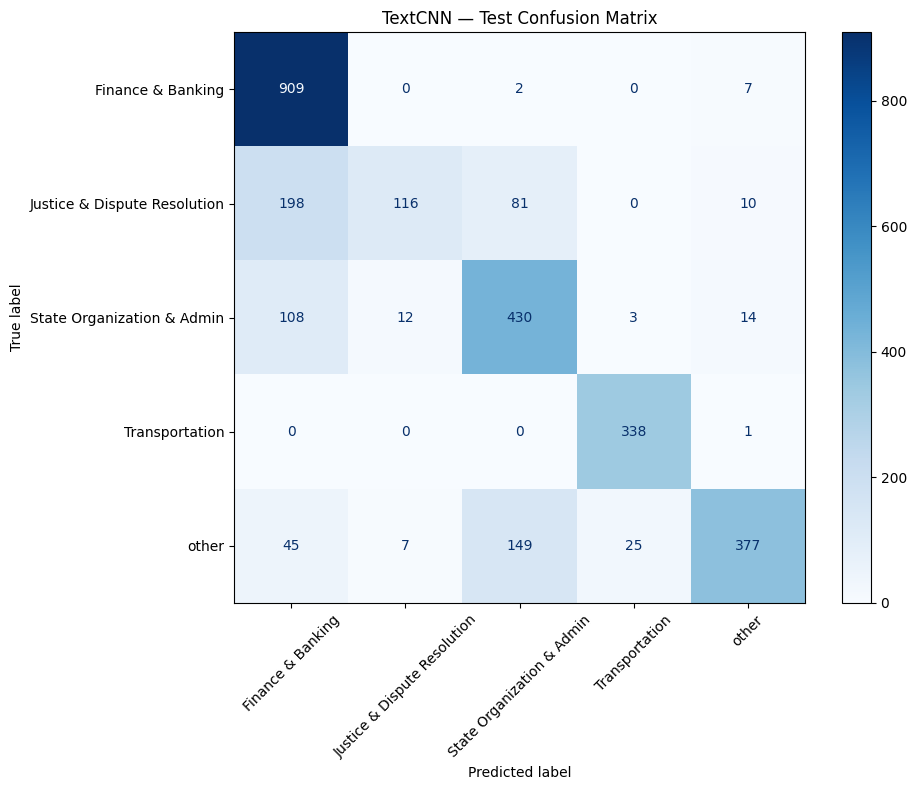

In [19]:
# Confusion matrix
cm = confusion_matrix(test['y_true'], test['y_pred'], labels=all_ids)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues', values_format='d', xticks_rotation=45)
ax.set_title('TextCNN — Test Confusion Matrix')
plt.tight_layout()
plt.savefig(str(ARTIFACT_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()


In [20]:
# Save artifacts
metadata = {
    'model_name': 'TextCNN', 'reference': 'Kim 2014',
    'max_len': MAX_LEN,
    'filter_sizes': list(FILTER_SIZES), 'num_filters': NUM_FILTERS,
    'dropout': DROPOUT, 'vocab_size': len(stoi), 'embed_dim': 300,
    'num_classes': num_classes, 'labels': labels,
    'label2id': {l: i for l, i in label2id.items()},
    'pad_token': PAD_TOKEN, 'unk_token': UNK_TOKEN, 'pad_idx': pad_idx,
    'best_val_macro_f1': best_macro_f1,
    'test_acc_top1': test['acc_top1'], 'test_acc_top3': test['acc_top3'],
    'test_macro_f1': test['macro_f1'], 'history': history,
}

with open(ARTIFACT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

with open(ARTIFACT_DIR / 'tokenizer_vocab.json', 'w', encoding='utf-8') as f:
    json.dump({'stoi': stoi, 'itos': itos}, f, ensure_ascii=False, indent=2)

print('Saved to', ARTIFACT_DIR)
print('Checkpoint:', best_path.name, f'({best_path.stat().st_size / 1e6:.1f} MB)')


Saved to experiments/textcnn_artifacts
Checkpoint: textcnn_best.pt (4.2 MB)
